# K-Means & PCA — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

The rule change: NO LABELS. Two questions survive — "are there groups?" (K-means, Blocks 4–6) and "which directions matter?" (PCA, Blocks 7–8) — and they team up in Block 8's pipeline.

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(77)

## Block 2 — Look at the data: the label column is GONE *(README §2.1)*

300 customers, 6 behavioral numbers each. Print the columns and confirm it yourself: nothing to predict, nothing to grade against. Welcome to most of the world's data.

   annual_income_k  spending_score  visits_per_month  avg_basket  \
0            112.1            36.9              8.30        76.4   
1             46.1            96.9             14.64        42.2   
2             87.0            34.5              5.65        67.5   
3             21.0            25.8              2.58         8.7   
4             45.8            85.0             12.02        39.7   

   online_ratio   age  
0         0.299  49.0  
1         0.919  24.3  
2         0.250  49.1  
3         0.435  36.2  
4         0.800  31.0  

columns: ['annual_income_k', 'spending_score', 'visits_per_month', 'avg_basket', 'online_ratio', 'age']
No 'label'. No target. Nobody will tell us who these customers are (README §2.1).


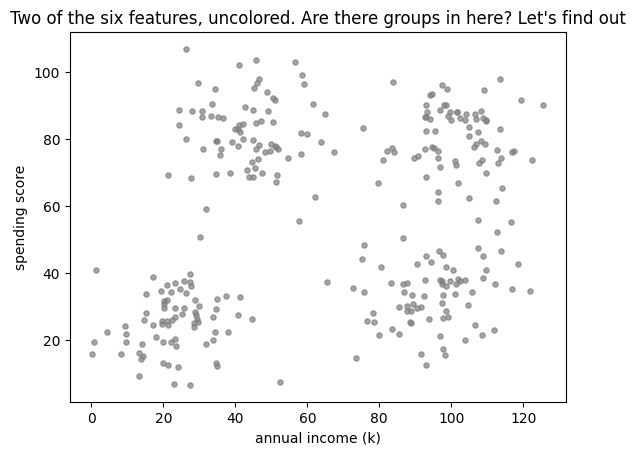

In [2]:
df = pd.read_csv("data/customer_data.csv")
print(df.head())
print(f"\ncolumns: {list(df.columns)}")
print("No 'label'. No target. Nobody will tell us who these customers are (README §2.1).")

X = df.values.astype(float)
FEATS = list(df.columns)
plt.scatter(X[:,0], X[:,1], s=14, color="gray", alpha=0.7)
plt.xlabel("annual income (k)"); plt.ylabel("spending score")
plt.title("Two of the six features, uncolored. Are there groups in here? Let's find out")
plt.show()

## Block 3 — Scaling: life-or-death for BOTH models *(README §4)*

K-means runs on distances (lesson 03's ruler); PCA runs on variances. Unscaled, income (~15–110) owns both: clustering becomes 'sort by income' and PC1 becomes 'the income axis'. One blind ruler, two blinded models.

In [3]:
mu, sd = X.mean(axis=0), X.std(axis=0)
Xs = (X - mu) / sd
print("feature stds BEFORE scaling:", dict(zip(FEATS, X.std(axis=0).round(1))))
print("income's variance share BEFORE:", f"{(X.std(0)**2)[0]/ (X.std(0)**2).sum():.0%}  <- it would own PCA outright")
print("after scaling: every feature contributes variance 1. Fair fight.")

feature stds BEFORE scaling: {'annual_income_k': np.float64(34.7), 'spending_score': np.float64(27.7), 'visits_per_month': np.float64(5.0), 'avg_basket': np.float64(24.9), 'online_ratio': np.float64(0.2), 'age': np.float64(8.1)}
income's variance share BEFORE: 45%  <- it would own PCA outright
after scaling: every feature contributes variance 1. Fair fight.


## Block 4 — The two dance steps *(README §2.2)*

ASSIGN: each point joins its nearest center — lesson 03's distance, verbatim. MOVE: each center relocates to its members' mean — the same humble mean that was lesson 08's round zero. That's the entire vocabulary of K-means.

In [4]:
def assign(Xs, centers):
    """README §2.2 step 1 — everyone joins the nearest center (lesson 03's ruler)."""
    d2 = ((Xs[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)   # every point x every center
    return d2.argmin(axis=1), d2.min(axis=1).sum()                   # memberships, inertia (README §3.1)

def move(Xs, memberships, k, old_centers):
    """README §2.2 step 2 — each center relocates to its members' average."""
    return np.array([Xs[memberships == j].mean(axis=0) if (memberships == j).any()
                     else old_centers[j] for j in range(k)])

## Block 5 — The dance itself *(README §3.1–3.2)*

Random start, then alternate the two steps until nobody switches teams. Watch the inertia column: it ONLY falls — each half-step is provably non-increasing, which is exactly why the dance must end (README §3.2).

The dance (K=4):
  iter  0 | inertia    763.3
  iter  1 | inertia    304.3
  iter  2 | inertia    232.4
  iter  3 | inertia    231.4
converged | final inertia 231.4


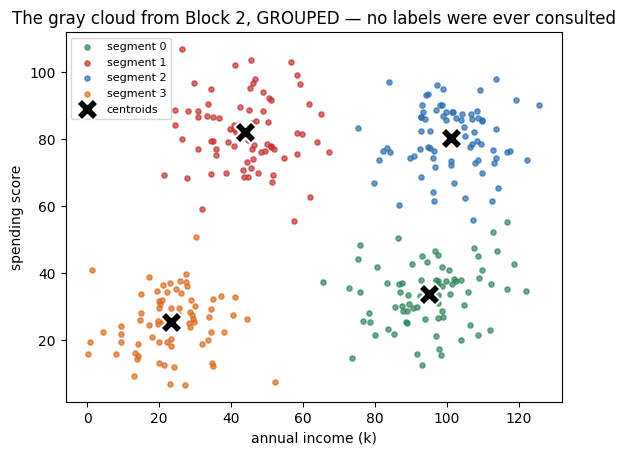

In [5]:
def kmeans(Xs, k, seed=0, max_iter=50):
    rs = np.random.default_rng(seed)
    centers = Xs[rs.choice(len(Xs), k, replace=False)]      # random opening position
    prev = None
    for it in range(max_iter):
        memberships, inertia = assign(Xs, centers)
        print(f"  iter {it:2d} | inertia {inertia:8.1f}") if it < 6 or prev is None else None
        if prev is not None and (memberships == prev).all():
            break                                           # nobody switched teams: converged
        centers = move(Xs, memberships, k, centers)
        prev = memberships
    return centers, memberships, inertia

print("The dance (K=4):")
centers, memb, inertia = kmeans(Xs, k=4, seed=1)
print(f"converged | final inertia {inertia:.1f}")

cols = ["#2f855a", "#c53030", "#2b6cb0", "#dd6b20"]
for j in range(4):
    plt.scatter(X[memb==j,0], X[memb==j,1], color=cols[j], s=14, alpha=0.7, label=f"segment {j}")
cent_real = centers * sd + mu
plt.scatter(cent_real[:,0], cent_real[:,1], marker="X", s=250, c="black", edgecolor="white", lw=1.5, label="centroids")
plt.xlabel("annual income (k)"); plt.ylabel("spending score"); plt.legend(fontsize=8)
plt.title("The gray cloud from Block 2, GROUPED — no labels were ever consulted")
plt.show()

## Block 6 — Choosing K: the elbow *(README §2.3 + §4)*

Inertia always falls as K grows (K = n scores a perfect, meaningless 0 — lesson 03's K=1 ghost in new clothes). Don't minimize it; find the bend. Note each K gets 5 restarts, best kept — the local-minima insurance from README §3.2.

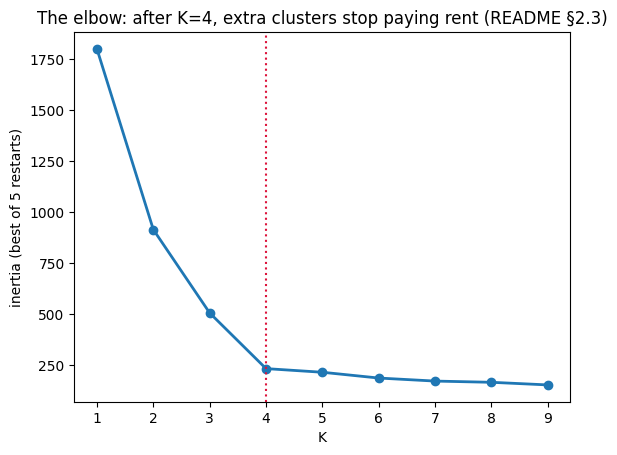

In [6]:
# quiet version of kmeans for sweeping
def kmeans_q(Xs, k, seed=0, max_iter=60):
    rs = np.random.default_rng(seed)
    centers = Xs[rs.choice(len(Xs), k, replace=False)]
    prev = None
    for _ in range(max_iter):
        m, inr = assign(Xs, centers)
        if prev is not None and (m == prev).all():
            break
        centers = move(Xs, m, k, centers)
        prev = m
    return centers, m, inr

inertias = [min(kmeans_q(Xs, k, seed=s)[2] for s in range(5)) for k in range(1, 10)]
plt.plot(range(1, 10), inertias, "o-", lw=2)
plt.axvline(4, color="crimson", ls=":")
plt.xlabel("K"); plt.ylabel("inertia (best of 5 restarts)")
plt.title("The elbow: after K=4, extra clusters stop paying rent (README §2.3)")
plt.show()

## Block 7 — PCA in five honest lines *(README §3.3–3.4)*

Center → covariance → eigenvectors (the stretch-directions) → sort by eigenvalue (the stretch-amounts) → project. Then the scree plot makes the data confess: how many dimensions is it REALLY?

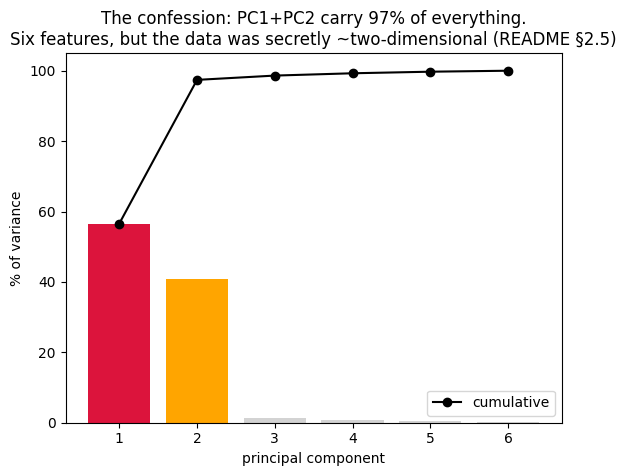

compressed: (300, 6) -> (300, 2), keeping 97% of the variance


In [7]:
Xc = Xs - Xs.mean(axis=0)                      # (already ~centered by scaling; belt & suspenders)
cov = np.cov(Xc.T)                             # how features vary TOGETHER — README §3.3
eigvals, eigvecs = np.linalg.eigh(cov)         # the stretch directions & amounts
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
ratio = eigvals / eigvals.sum()

plt.bar(range(1, 7), ratio*100, color=["crimson", "orange"] + ["lightgray"]*4)
plt.plot(range(1, 7), np.cumsum(ratio)*100, "o-", color="black", label="cumulative")
plt.xlabel("principal component"); plt.ylabel("% of variance"); plt.legend()
plt.title(f"The confession: PC1+PC2 carry {ratio[:2].sum():.0%} of everything.\nSix features, but the data was secretly ~two-dimensional (README §2.5)")
plt.show()

Z = Xc @ eigvecs[:, :2]                        # 6 numbers per customer -> 2 (README §3.4)
print(f"compressed: {Xc.shape} -> {Z.shape}, keeping {ratio[:2].sum():.0%} of the variance")

## Block 8 — The payoff pipeline, and turning geometry into meaning *(README §2.5 + §5)*

Cluster in the compressed space, then do the honest work: READ the centroids (as customer profiles) and READ the loadings (each PC as a recipe over real features). Geometry becomes meaning only through this reading — never automatically.

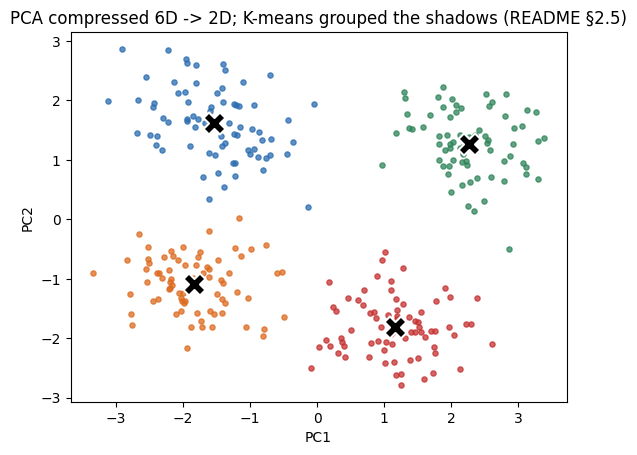

PC loadings — each component is a RECIPE over real features (README §5):
  PC1 biggest ingredients: spending_score:-0.53, visits_per_month:-0.53, online_ratio:-0.48
  PC2 biggest ingredients: annual_income_k:-0.59, avg_basket:-0.55, age:-0.52

Centroid profiles (in real units) — the reading that makes segments MEAN something:
           annual_income_k  spending_score  visits_per_month  avg_basket  \
segment 0             23.4            25.4               2.4        17.0   
segment 1             95.0            33.7               6.9        66.7   
segment 2             44.0            82.1              12.2        37.6   
segment 3            101.1            80.3              14.5        76.7   

           online_ratio   age  
segment 0           0.4  39.9  
segment 1           0.3  50.0  
segment 2           0.8  29.5  
segment 3           0.7  39.9  


In [8]:
cent2, memb2, _ = kmeans_q(Z, 4, seed=3)
for j in range(4):
    plt.scatter(Z[memb2==j,0], Z[memb2==j,1], color=cols[j], s=14, alpha=0.75)
plt.scatter(cent2[:,0], cent2[:,1], marker="X", s=250, c="black", edgecolor="white", lw=1.5)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA compressed 6D -> 2D; K-means grouped the shadows (README §2.5)")
plt.show()

print("PC loadings — each component is a RECIPE over real features (README §5):")
for pc in range(2):
    recipe = ", ".join(f"{FEATS[i]}:{eigvecs[i, pc]:+.2f}" for i in np.argsort(-np.abs(eigvecs[:, pc]))[:3])
    print(f"  PC{pc+1} biggest ingredients: {recipe}")
print()
print("Centroid profiles (in real units) — the reading that makes segments MEAN something:")
prof = np.array([X[memb2 == j].mean(axis=0) for j in range(4)])
print(pd.DataFrame(prof.round(1), columns=FEATS, index=[f"segment {j}" for j in range(4)]))

## Block 9 — Break both, on purpose *(README §4 + §6)*

(a) Two crescent moons: K-means' round-blob belief slices straight through them — confidently, wrongly. (b) The local-minimum trap: one bad start leaves a visibly worse partition than the best of ten restarts. Neither failure prints an error message. Unsupervised failures never do.

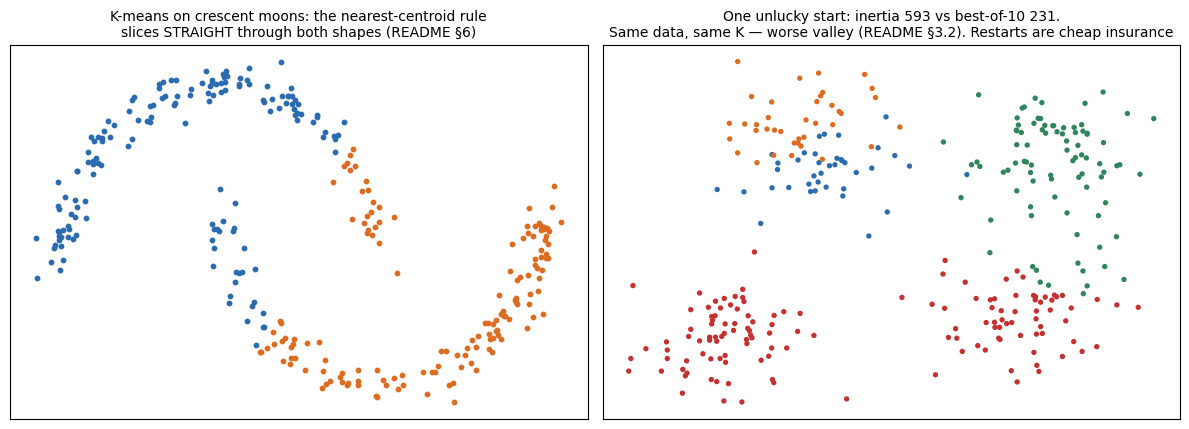

In [9]:
# (a) moons vs the blob belief
rs = np.random.default_rng(4)
t1 = rs.uniform(0, np.pi, 150); t2 = rs.uniform(0, np.pi, 150)
moons = np.vstack([np.c_[np.cos(t1), np.sin(t1)],
                   np.c_[1 - np.cos(t2), 0.4 - np.sin(t2)]]) + rs.normal(0, 0.06, (300, 2))
_, mm, _ = kmeans_q(moons, 2, seed=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(moons[mm==0,0], moons[mm==0,1], s=10, color="#2b6cb0")
axes[0].scatter(moons[mm==1,0], moons[mm==1,1], s=10, color="#dd6b20")
axes[0].set_title("K-means on crescent moons: the nearest-centroid rule\nslices STRAIGHT through both shapes (README §6)", fontsize=10)

# (b) the local-minimum trap
worst = max((kmeans_q(Xs, 4, seed=s) for s in range(10)), key=lambda r: r[2])
best  = min((kmeans_q(Xs, 4, seed=s) for s in range(10)), key=lambda r: r[2])
axes[1].scatter(X[:,0], X[:,1], s=8, c=[cols[j] for j in worst[1]])
axes[1].set_title(f"One unlucky start: inertia {worst[2]:.0f} vs best-of-10 {best[2]:.0f}.\nSame data, same K — worse valley (README §3.2). Restarts are cheap insurance", fontsize=10)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Block 10 — Reconstruction, and the sharpest PCA warning *(README §3.4 + §6)*

(a) Run the projection backwards: 2 numbers rebuild 6 surprisingly well — the discarded eigenvalues ARE the reconstruction error. (b) Variance ≠ importance: a tiny synthetic example where the class signal lives in the QUIET direction, and PC1-only compression destroys it.

In [10]:
# (a) reconstruction from 2 components
X_rec = (Z @ eigvecs[:, :2].T) * sd + mu
err = np.abs(X_rec - X).mean(axis=0)
print("mean absolute reconstruction error per feature (from just 2 numbers per customer):")
for f, e, s_ in zip(FEATS, err, X.std(axis=0)):
    print(f"  {f:18s} {e:6.2f}   (feature std {s_:6.2f})")

# (b) variance != importance
rs = np.random.default_rng(9)
loud = rs.normal(0, 3.0, 400)                     # big variance, NO class information
quiet = np.where(rs.uniform(size=400) < 0.5, -0.4, 0.4) + rs.normal(0, 0.08, 400)  # tiny variance, ALL the signal
Xtoy = np.c_[loud, quiet]
label = (quiet > 0).astype(int)                   # (labels used ONLY to grade the damage, not to fit)
covt = np.cov(Xtoy.T)
vt, Vt = np.linalg.eigh(covt); Vt = Vt[:, np.argsort(vt)[::-1]]
z1 = Xtoy @ Vt[:, 0]                              # keep PC1 only
sep_before = abs(Xtoy[label==1, 1].mean() - Xtoy[label==0, 1].mean()) / Xtoy[:,1].std()
sep_after  = abs(z1[label==1].mean() - z1[label==0].mean()) / z1.std()
print(f"\nclass separation BEFORE PCA (along the quiet axis): {sep_before:.1f} stds  <- trivially separable")
print(f"class separation AFTER keeping PC1 only          : {sep_after:.2f} stds  <- signal destroyed")
print("PCA kept the LOUD direction and threw away the IMPORTANT one (README §6).")
print("Variance-greedy, label-blind: know this before compressing away your signal.")

mean absolute reconstruction error per feature (from just 2 numbers per customer):
  annual_income_k      3.16   (feature std  34.70)
  spending_score       3.21   (feature std  27.69)
  visits_per_month     0.60   (feature std   5.00)
  avg_basket           2.64   (feature std  24.87)
  online_ratio         0.03   (feature std   0.20)
  age                  1.38   (feature std   8.05)

class separation BEFORE PCA (along the quiet axis): 2.0 stds  <- trivially separable
class separation AFTER keeping PC1 only          : 0.02 stds  <- signal destroyed
PCA kept the LOUD direction and threw away the IMPORTANT one (README §6).
Variance-greedy, label-blind: know this before compressing away your signal.


---
## What you now own

- The rule change: what learning means when nobody supplies answers
- K-means as a two-step dance you already knew (lesson 03's ruler + the mean), why it must converge, and why it needs restarts
- PCA as shadow-finding: covariance, eigen-directions, the scree confession, projection & reconstruction
- The workhorse pipeline (compress, then cluster) and the discipline of reading centroids & loadings before believing them
- The honest failures: moons vs blobs, local minima, and variance ≠ importance

**Next:** `kmeans_pca_with_library.ipynb` to verify against sklearn — then folder `10-neural-networks`: the deep learning arc begins, and lesson 01's loop returns wearing a cape.